# Install Libraries

In [1]:
# Install required libraries
!pip install opencv-python-headless pandas matplotlib webcolors Pillow

#  Import Libraries

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import webcolors
import io

# Load Color CSV Dataset

In [3]:
# We'll use a colors.csv with columns: color, color_name, hex, R, G, B
# Download a standard color dataset
!wget -q https://raw.githubusercontent.com/codebrainz/color-names/master/output/colors.csv -O colors.csv

# If above fails, create a basic one manually:
import os
if not os.path.exists('colors.csv') or os.path.getsize('colors.csv') < 100:
    colors_data = {
        'color': ['black','white','red','lime','blue','yellow','cyan','magenta',
                  'silver','gray','maroon','olive','green','purple','teal','navy',
                  'orange','pink','brown','coral','gold','ivory','lavender','salmon'],
        'color_name': ['Black','White','Red','Lime','Blue','Yellow','Cyan','Magenta',
                       'Silver','Gray','Maroon','Olive','Green','Purple','Teal','Navy',
                       'Orange','Pink','Brown','Coral','Gold','Ivory','Lavender','Salmon'],
        'hex': ['#000000','#ffffff','#ff0000','#00ff00','#0000ff','#ffff00',
                '#00ffff','#ff00ff','#c0c0c0','#808080','#800000','#808000',
                '#008000','#800080','#008080','#000080','#ffa500','#ffc0cb',
                '#a52a2a','#ff7f50','#ffd700','#fffff0','#e6e6fa','#fa8072'],
        'R': [0,255,255,0,0,255,0,255,192,128,128,128,0,128,0,0,255,255,165,255,255,255,230,250],
        'G': [0,255,0,255,0,255,255,0,192,128,0,128,128,0,128,0,165,192,42,127,215,255,230,128],
        'B': [0,255,0,0,255,0,255,255,192,128,0,0,0,128,128,128,0,203,42,80,0,240,250,114]
    }
    df = pd.DataFrame(colors_data)
    df.to_csv('colors.csv', index=False)
    print("✅ Basic color dataset created!")
else:
    print("✅ Color dataset loaded!")

df = pd.read_csv('colors.csv', header=None,
                 names=['color','color_name','hex','R','G','B'])
print(f"Total colors in database: {len(df)}")
df.head()

✅ Color dataset loaded!
Total colors in database: 865


,color,color_name,hex,R,G,B
0,air_force_blue_raf,Air Force Blue (Raf),#5d8aa8,93,138,168
1,air_force_blue_usaf,Air Force Blue (Usaf),#00308f,0,48,143
2,air_superiority_blue,Air Superiority Blue,#72a0c1,114,160,193
3,alabama_crimson,Alabama Crimson,#a32638,163,38,56
4,alice_blue,Alice Blue,#f0f8ff,240,248,255


# Color Detection Function

In [4]:
def get_color_name(R, G, B):
    """Find the closest color name for given RGB values."""
    minimum = float('inf')
    color_name = "Unknown"

    for i in range(len(df)):
        d = abs(R - int(df.loc[i, 'R'])) + \
            abs(G - int(df.loc[i, 'G'])) + \
            abs(B - int(df.loc[i, 'B']))
        if d < minimum:
            minimum = d
            color_name = df.loc[i, 'color_name']

    return color_name

def rgb_to_hex(r, g, b):
    """Convert RGB to HEX string."""
    return f"#{r:02x}{g:02x}{b:02x}".upper()

def detect_dominant_colors(image_path, num_colors=5):
    """Detect dominant colors in an image using K-Means clustering."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Reshape to list of pixels
    pixels = img.reshape(-1, 3).astype(np.float32)

    # Apply K-Means clustering
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    _, labels, centers = cv2.kmeans(
        pixels, num_colors, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
    )

    # Count pixels per cluster
    unique, counts = np.unique(labels, return_counts=True)
    total_pixels = len(labels)

    results = []
    for i, (center, count) in enumerate(zip(centers, counts)):
        r, g, b = int(center[0]), int(center[1]), int(center[2])
        name = get_color_name(r, g, b)
        hex_code = rgb_to_hex(r, g, b)
        percentage = round((count / total_pixels) * 100, 2)
        results.append({
            'Color Name': name,
            'R': r, 'G': g, 'B': b,
            'HEX': hex_code,
            'Percentage': percentage
        })

    # Sort by percentage
    results = sorted(results, key=lambda x: x['Percentage'], reverse=True)
    return img, results

print("✅ Color detection functions ready!")

✅ Color detection functions ready!


# Visualization Function

In [5]:
def visualize_colors(image_path, num_colors=5):
    """Main function: detect and visualize dominant colors."""
    img, results = detect_dominant_colors(image_path, num_colors)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#1a1a2e')

    # --- Left: Original Image ---
    axes[0].imshow(img)
    axes[0].set_title('📷 Original Image', color='white', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # --- Right: Color Palette ---
    palette_img = np.zeros((300, 500, 3), dtype=np.uint8)
    y_start = 0

    for res in results:
        height = int((res['Percentage'] / 100) * 300)
        color_rgb = (res['R'], res['G'], res['B'])
        palette_img[y_start:y_start+height, :] = color_rgb
        y_start += height

    axes[1].imshow(palette_img)
    axes[1].set_title('🎨 Dominant Color Palette', color='white', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('color_palette_output.png', dpi=150, bbox_inches='tight',
                facecolor='#1a1a2e')
    plt.show()
    print("\n✅ Saved: color_palette_output.png")

    # --- Print Results Table ---
    print("\n" + "="*60)
    print("🎨 DETECTED COLORS BREAKDOWN")
    print("="*60)
    print(f"{'Rank':<6}{'Color Name':<20}{'R':>5}{'G':>5}{'B':>5}  {'HEX':<10}{'%':>8}")
    print("-"*60)
    for i, res in enumerate(results, 1):
        bar = "█" * int(res['Percentage'] / 5)
        print(f"{i:<6}{res['Color Name']:<20}{res['R']:>5}{res['G']:>5}{res['B']:>5}  "
              f"{res['HEX']:<10}{res['Percentage']:>7}%  {bar}")
    print("="*60)

    return results

print("✅ Visualization function ready!")

✅ Visualization function ready!


# Click on Image to Detect Color (Interactive)

In [6]:
def analyze_single_pixel(image_path, x_percent=50, y_percent=50):
    """Detect color at a specific location in the image."""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]
    x = int(w * x_percent / 100)
    y = int(h * y_percent / 100)

    r, g, b = img_rgb[y, x]
    r, g, b = int(r), int(g), int(b)
    color_name = get_color_name(r, g, b)
    hex_code = rgb_to_hex(r, g, b)

    # Show result
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Image with point
    axes[0].imshow(img_rgb)
    axes[0].plot(x, y, 'wo', markersize=15, markeredgecolor='black', markeredgewidth=2)
    axes[0].set_title(f'📍 Selected Point ({x}, {y})', fontsize=12)
    axes[0].axis('off')

    # Color swatch
    swatch = np.full((200, 300, 3), [r, g, b], dtype=np.uint8)
    axes[1].imshow(swatch)
    axes[1].set_title(
        f'🎨 {color_name}\nRGB({r}, {g}, {b})  HEX: {hex_code}',
        fontsize=13, fontweight='bold'
    )
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n📌 Color at ({x_percent}%, {y_percent}%) of image:")
    print(f"   Name  : {color_name}")
    print(f"   RGB   : ({r}, {g}, {b})")
    print(f"   HEX   : {hex_code}")

print("✅ Single pixel analyzer ready!")

✅ Single pixel analyzer ready!


# Upload & Run!

📂 Please upload an image file...


Saving colorful-fruit-bowl-stockcake.webp to colorful-fruit-bowl-stockcake.webp

✅ Uploaded: colorful-fruit-bowl-stockcake.webp

🔍 Analyzing dominant colors...



/tmp/ipykernel_810/4069558047.py:27: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_810/4069558047.py:27: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_810/4069558047.py:28: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig('color_palette_output.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_810/4069558047.py:28: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.savefig('color_palette_output.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

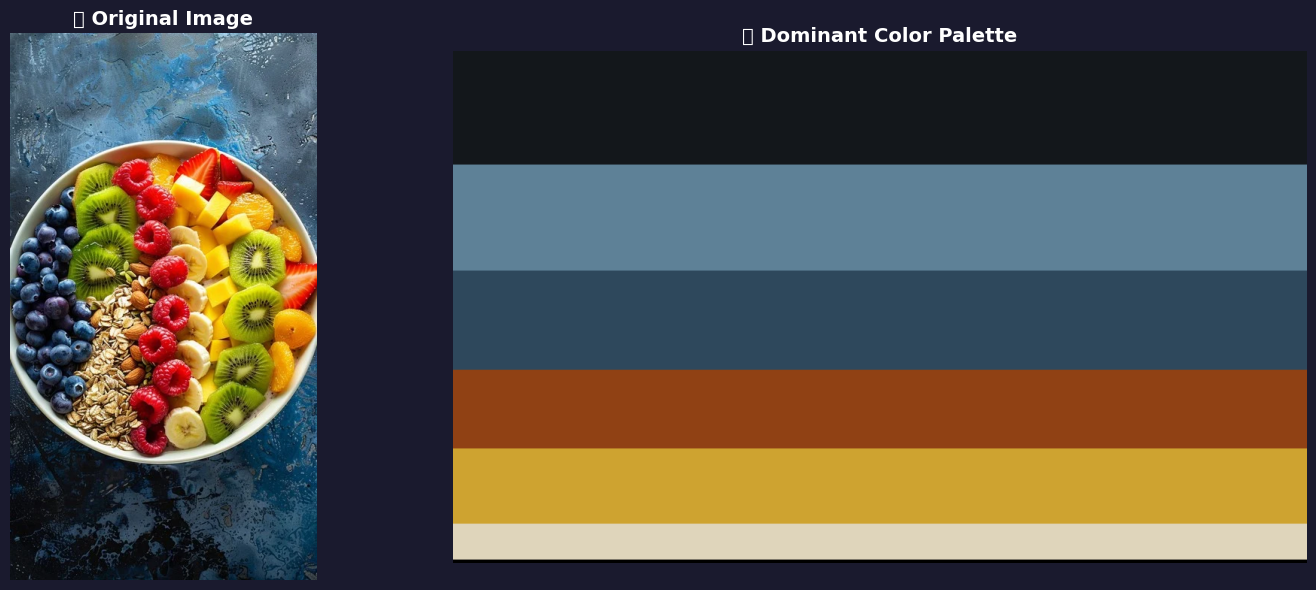


✅ Saved: color_palette_output.png

🎨 DETECTED COLORS BREAKDOWN
Rank  Color Name              R    G    B  HEX              %
------------------------------------------------------------
1     Licorice               19   23   27  #13171B      22.4%  ████
2     Slate Gray             94  129  151  #5E8197     20.67%  ████
3     Dark Slate Gray        46   72   92  #2E485C     19.47%  ███
4     Saddle Brown          144   65   20  #904114     15.43%  ███
5     Satin Sheen Gold      206  163   48  #CEA330     14.92%  ██
6     Bone                  223  213  187  #DFD5BB      7.11%  █

🔍 Detecting color at center of image...


/tmp/ipykernel_810/960448450.py:33: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_810/960448450.py:33: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


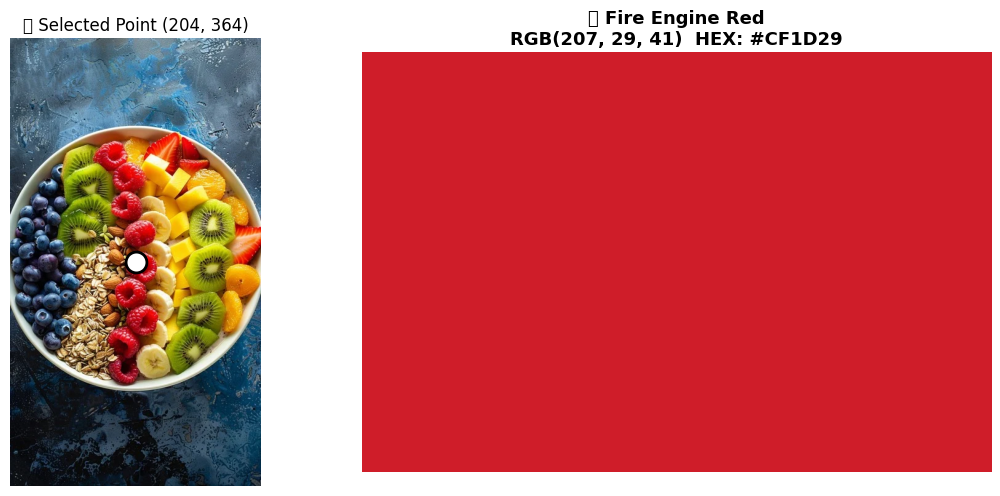


📌 Color at (50%, 50%) of image:
   Name  : Fire Engine Red
   RGB   : (207, 29, 41)
   HEX   : #CF1D29


In [7]:
# ── UPLOAD YOUR IMAGE ──────────────────────────────────────────
print("📂 Please upload an image file...")
uploaded = files.upload()

image_filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {image_filename}")

# ── DETECT DOMINANT COLORS ─────────────────────────────────────
print("\n🔍 Analyzing dominant colors...\n")
results = visualize_colors(image_filename, num_colors=6)

# ── DETECT COLOR AT CENTER ─────────────────────────────────────
print("\n🔍 Detecting color at center of image...")
analyze_single_pixel(image_filename, x_percent=50, y_percent=50)

# Export Results to CSV

In [8]:
# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv('detected_colors.csv', index=False)
print("✅ Results saved to detected_colors.csv")
print(results_df)

# Download files
files.download('detected_colors.csv')
files.download('color_palette_output.png')

✅ Results saved to detected_colors.csv
         Color Name    R    G    B      HEX  Percentage
0          Licorice   19   23   27  #13171B       22.40
1        Slate Gray   94  129  151  #5E8197       20.67
2   Dark Slate Gray   46   72   92  #2E485C       19.47
3      Saddle Brown  144   65   20  #904114       15.43
4  Satin Sheen Gold  206  163   48  #CEA330       14.92
5              Bone  223  213  187  #DFD5BB        7.11


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>